# Customer Churn Prediction — Upgraded Notebook
**Instacart Dataset | 7-Step Pipeline as per Architecture Diagram**

---

## 📦 Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, auc
)
from xgboost import XGBClassifier

---
## STEP 01 — Data EDA
**Scope:** Load all 6 CSVs. Inspect schema, data types, null values, outliers, and key distributions.



In [2]:
# ── Load all 6 source CSVs
orders       = pd.read_csv('orders.csv')
order_prior  = pd.read_csv('order_products__prior.csv')
order_train  = pd.read_csv('order_products__train.csv')
products     = pd.read_csv('products.csv')
aisles       = pd.read_csv('aisles.csv')
departments  = pd.read_csv('departments.csv')

print('=== orders.csv ===')
print('Shape       :', orders.shape)
print('Dtypes      :\n', orders.dtypes)
print('Null counts :\n', orders.isnull().sum())
print('\nDescriptive Stats:')
display(orders.describe())
display(orders.head())

=== orders.csv ===
Shape       : (3421083, 7)
Dtypes      :
 order_id                    int64
user_id                     int64
eval_set                      str
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object
Null counts :
 order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Descriptive Stats:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
mean,1.710542e+06,1.029782e+05,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01
max,3.421083e+06,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


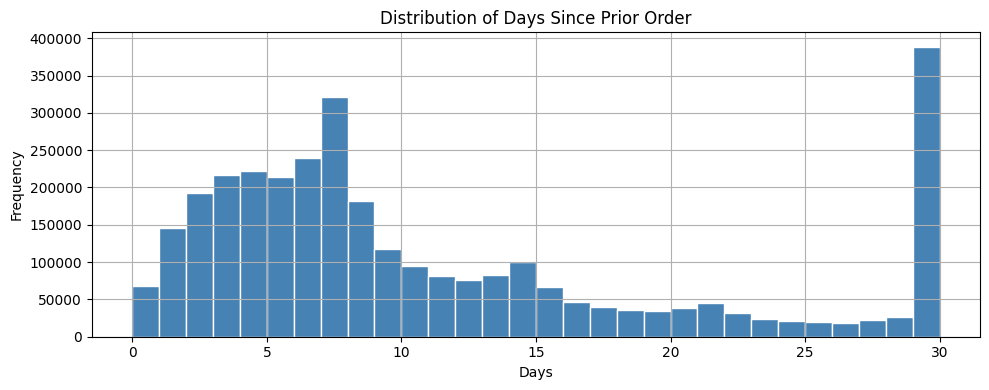

Outlier rows (IQR method): 0


In [3]:
# ── Distribution of days between orders (outlier check)
plt.figure(figsize=(10, 4))
orders['days_since_prior_order'].dropna().hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Days Since Prior Order')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Outlier flag: IQR method
Q1 = orders['days_since_prior_order'].quantile(0.25)
Q3 = orders['days_since_prior_order'].quantile(0.75)
IQR = Q3 - Q1
outliers = orders[orders['days_since_prior_order'] > Q3 + 1.5 * IQR]
print(f'Outlier rows (IQR method): {len(outliers)}')

In [4]:
# ── Fill missing days_since_prior_order (first-ever orders have no prior — treat as 0)
orders['days_since_prior_order'] = orders['days_since_prior_order'].fillna(0)

---
## STEP 02 — Data Merging
**Scope:** Join orders + products + aisles + departments into a single enriched table.

In [5]:
# ── Add aisle and department names to products
products = products.merge(aisles,      on='aisle_id')
products = products.merge(departments, on='department_id')

# ── Add product details to prior orders
order_prior = order_prior.merge(products, on='product_id')

# ── Add order-level info to prior orders
order_prior = order_prior.merge(orders, on='order_id')

print('Merged order_prior shape:', order_prior.shape)
display(order_prior.head(3))

Merged order_prior shape: (32434489, 15)


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8.0


---
## STEP 03 — Feature Engineering
**Scope:** Aggregate raw order data up to the **customer level**. We engineer 7 behavioural features that describe each unique customer.

In [ ]:
# ── Step 1: Sort orders chronologically per customer
orders_sorted = orders.sort_values(['user_id', 'order_number'])

# ── Step 2: Separate last order per customer (used for label only)
last_orders = orders_sorted.groupby('user_id').last().reset_index()
last_orders = last_orders[['user_id', 'days_since_prior_order']]
last_orders.columns = ['user_id', 'days_since_last_actual']

# ── Step 3: All orders EXCEPT the last one → used for feature building
# This is the leakage fix: features are computed from historical data only
all_except_last = orders_sorted.groupby('user_id').head(-1)

# ── Step 4: Filter to prior eval_set only for feature computation
prior_except_last = all_except_last[all_except_last['eval_set'] == 'prior']

# ── Step 5: Build customer-level features from historical orders only
customer_features = prior_except_last.groupby('user_id').agg(
    total_orders       = ('order_number',          'max'),
    median_days_between= ('days_since_prior_order', 'median'),   # FIX: median not mean
    gap_std            = ('days_since_prior_order', 'std'),       # NEW: consistency signal
    avg_hour_of_order  = ('order_hour_of_day',      'mean'),
    most_common_dow    = ('order_dow', lambda x: x.mode()[0])
).reset_index()

# Fill NaN in gap_std (customers with only 1 prior order have no std)
customer_features['gap_std'] = customer_features['gap_std'].fillna(0)

# ── Reorder ratio per customer (loyalty signal) — from prior orders except last
prior_products_except_last = order_prior[order_prior['user_id'].isin(prior_except_last['user_id'])]
reorder_ratio = prior_products_except_last.groupby('user_id')['reordered'].mean().reset_index()
reorder_ratio.columns = ['user_id', 'reorder_ratio']

# ── Average basket size per customer
basket_size = prior_products_except_last.groupby(['user_id', 'order_id']).size().reset_index(name='basket_size')
avg_basket  = basket_size.groupby('user_id')['basket_size'].mean().reset_index()
avg_basket.columns = ['user_id', 'avg_basket_size']

# ── Top department per customer
top_dept = prior_products_except_last.groupby(['user_id', 'department'])['order_id'].count()
top_dept = top_dept.reset_index().sort_values('order_id', ascending=False)
top_dept = top_dept.drop_duplicates('user_id')[['user_id', 'department']]
top_dept.columns = ['user_id', 'top_department']

# ── Merge all features
customer_df = customer_features \
    .merge(reorder_ratio, on='user_id', how='left') \
    .merge(avg_basket,    on='user_id', how='left') \
    .merge(top_dept,      on='user_id', how='left')

# Fill any remaining NaNs from left joins
customer_df['reorder_ratio']  = customer_df['reorder_ratio'].fillna(0)
customer_df['avg_basket_size']= customer_df['avg_basket_size'].fillna(0)
customer_df['top_department'] = customer_df['top_department'].fillna('unknown')

print('Engineered features shape:', customer_df.shape)
print('Features:', customer_df.columns.tolist())
display(customer_df.head())


Engineered features shape: (206209, 9)
Features: ['user_id', 'total_orders', 'median_days_between', 'gap_std', 'avg_hour_of_order', 'most_common_dow', 'reorder_ratio', 'avg_basket_size', 'top_department']


,user_id,total_orders,median_days_between,gap_std,avg_hour_of_order,most_common_dow,reorder_ratio,avg_basket_size,top_department
0,1,10,19.5,10.803292,10.300000,1,0.694915,5.900000,snacks
1,2,14,11.5,10.316955,10.571429,1,0.476923,13.928571,dairy eggs
2,3,12,10.0,6.200562,16.416667,0,0.625000,7.333333,produce
3,4,5,15.0,10.271319,12.600000,4,0.055556,3.600000,frozen
4,5,4,10.5,7.788881,16.000000,3,0.378378,9.250000,produce


---
## STEP 04 — Label Engineering (Churn Column)
> **Churn column is added to: `customer_df`** — the customer-level aggregated dataframe.

In [ ]:
# ══════════════════════════════════════════════════════════════
# STEP 04 — Label Engineering
# CHURN DEFINITION: Customer has not placed an order in 29+ days

CHURN_THRESHOLD = 29  # days of inactivity = churned

# ── Merge the last gap (label source) into customer_df
customer_df = customer_df.merge(last_orders, on='user_id', how='left')

# ── Create churn label from the HELD-OUT last order gap
customer_df['churned'] = (
    customer_df['days_since_last_actual'] >= CHURN_THRESHOLD
).astype(int)

# ── Drop the label source column — must NOT enter model as a feature
customer_df = customer_df.drop(columns=['days_since_last_actual'], errors='ignore')

print(f'=== Churn Definition: >= {CHURN_THRESHOLD} days of inactivity ===')
print(f'Dataset shape: {customer_df.shape}')
print(f'\nChurn value distribution:')
print(customer_df['churned'].value_counts())
print(f'\nChurn rate: {customer_df["churned"].mean()*100:.1f}%')

print('\n=== Sample rows showing the churned column ===')
display(customer_df[['user_id', 'total_orders', 'median_days_between',
                      'gap_std', 'reorder_ratio', 'churned']].head(10))


=== Churn Definition: >= 29 days of inactivity ===
Dataset shape: (206209, 14)

Churn value distribution:
churned
0    140808
1     65401
Name: count, dtype: int64

Churn rate: 31.7%

=== Sample rows showing the churned column ===


,user_id,total_orders,median_days_between,gap_std,reorder_ratio,churned
0,1,10,19.5,10.803292,0.694915,0
1,2,14,11.5,10.316955,0.476923,1
2,3,12,10.0,6.200562,0.625000,0
3,4,5,15.0,10.271319,0.055556,1
4,5,4,10.5,7.788881,0.378378,0
5,6,3,6.0,6.000000,0.142857,0
6,7,20,7.0,9.045354,0.669903,0
7,8,3,30.0,17.320508,0.265306,0
8,9,3,6.0,15.874508,0.236842,1
9,10,5,14.0,11.410521,0.342657,1


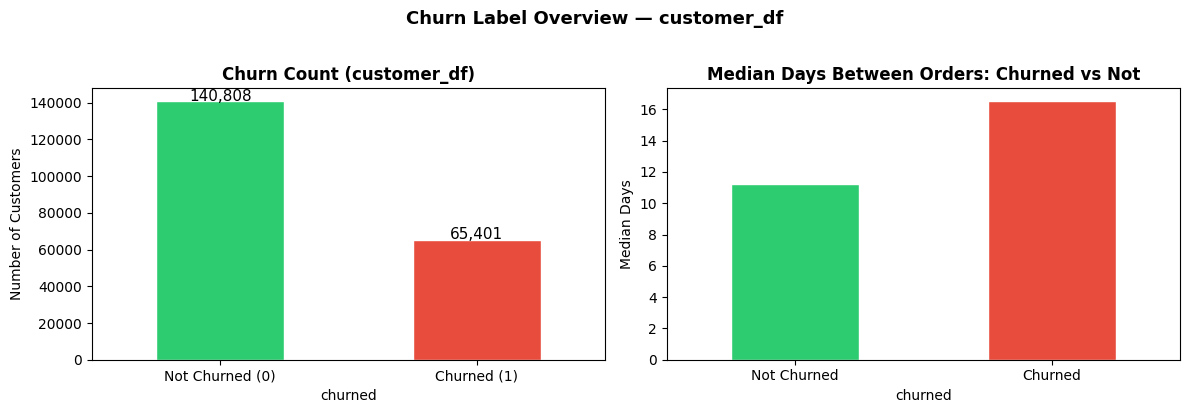

In [27]:
# ── Churn distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
customer_df['churned'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
    edgecolor='white', width=0.5
)
axes[0].set_title('Churn Count (customer_df)', fontweight='bold')
axes[0].set_xticklabels(['Not Churned (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Number of Customers')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=11)

# Median days between orders: churned vs not
customer_df.groupby('churned')['median_days_between'].mean().plot(
    kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
    edgecolor='white', width=0.5
)
axes[1].set_title('Median Days Between Orders: Churned vs Not', fontweight='bold')
axes[1].set_xticklabels(['Not Churned', 'Churned'], rotation=0)
axes[1].set_ylabel('Median Days')

plt.suptitle('Churn Label Overview — customer_df', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## STEP 05 — Preprocessing
**Scope:** Encode categoricals → Select features using data-driven methods → Scale → Train-test split.

### Feature Selection: 3-Method Approach

We run **three methods** in sequence and select features that score well across multiple approaches:

- **Method 0 — Pearson Correlation (Baseline):** Fast sanity check. Only detects linear relationships. Low score doesn't disqualify a feature.
- **Method 1 — Mutual Information:** Captures non-linear relationships using information theory. More reliable for binary classification.
- **Method 2 — XGBoost Feature Importance:** Tree-based importance reflecting real-world predictive contribution.

> A feature earns its place by showing signal in **at least 2 of the 3 methods**.

In [ ]:
# ── Encode categorical feature
le = LabelEncoder()
customer_df['top_department_enc'] = le.fit_transform(customer_df['top_department'])

# ── All candidate numeric features
candidate_features = [
    'total_orders', 'median_days_between', 'gap_std',
    'avg_hour_of_order', 'most_common_dow',
    'reorder_ratio', 'avg_basket_size', 'top_department_enc'
]

X_all = customer_df[candidate_features]
y     = customer_df['churned']

print('Candidate features:', candidate_features)
print('X shape:', X_all.shape)
print('Class balance:')
print(y.value_counts())


Candidate features: ['total_orders', 'median_days_between', 'gap_std', 'avg_hour_of_order', 'most_common_dow', 'reorder_ratio', 'avg_basket_size', 'top_department_enc']
X shape: (206209, 8)
Class balance:
churned
0    140808
1     65401
Name: count, dtype: int64


=== Pearson Correlation with Churn (Baseline) ===
Range: -1 (inverse) to +1 (perfect linear). Near 0 = no linear signal.
total_orders          -0.2864
reorder_ratio         -0.2516
avg_basket_size       -0.0471
top_department_enc    -0.0324
most_common_dow       -0.0281
avg_hour_of_order      0.0340
median_days_between    0.3062
gap_std                0.3612


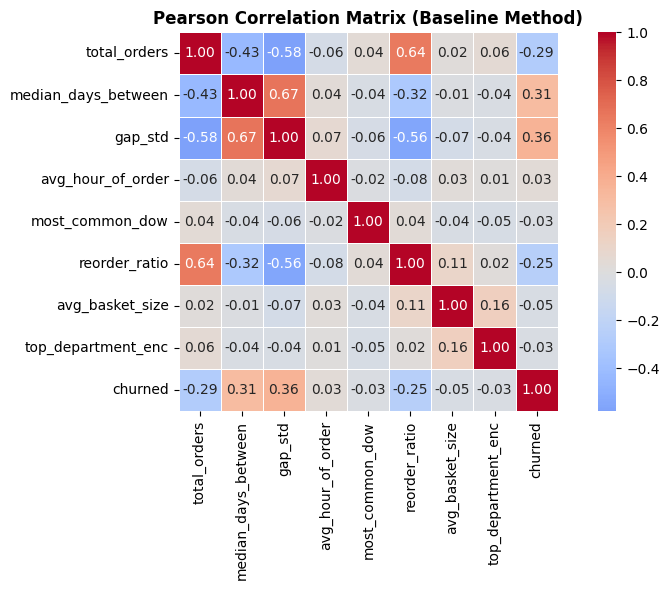

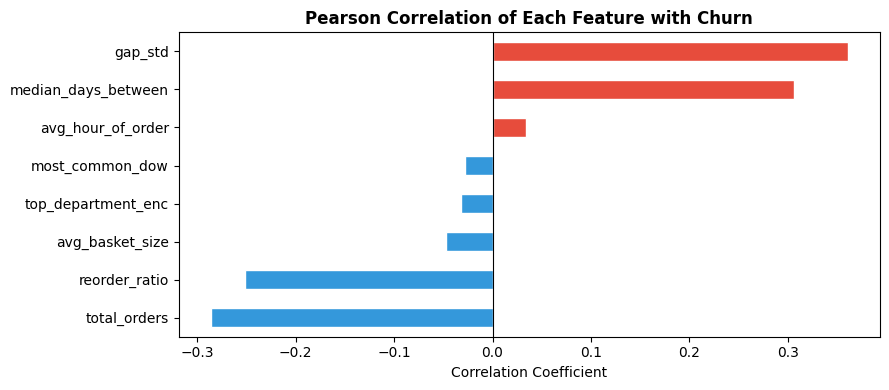

In [29]:
# ══════════════════════════════════════════════════════════════
# METHOD 0 (Baseline): Pearson Correlation Matrix
# Measures LINEAR relationship between each numeric feature
# and the churn label. Simple but limited — misses non-linear
# signals.
# ══════════════════════════════════════════════════════════════

numeric_df   = customer_df[candidate_features + ['churned']].select_dtypes(include=[np.number])
correlations = numeric_df.corr()['churned'].drop('churned').sort_values(ascending=True)

print('=== Pearson Correlation with Churn (Baseline) ===')
print('Range: -1 (inverse) to +1 (perfect linear). Near 0 = no linear signal.')
print(correlations.round(4).to_string())

# ── Heatmap: full correlation matrix
plt.figure(figsize=(9, 6))
sns.heatmap(
    numeric_df.corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, square=True
)
plt.title('Pearson Correlation Matrix (Baseline Method)', fontweight='bold')
plt.tight_layout()
plt.show()

# ── Bar chart: correlation with churn only
plt.figure(figsize=(9, 4))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in correlations]
correlations.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Pearson Correlation of Each Feature with Churn', fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


=== Mutual Information Scores (higher = more informative) ===
            Feature  MI_Score
            gap_std  0.079683
       total_orders  0.061874
median_days_between  0.050229
      reorder_ratio  0.045302
  avg_hour_of_order  0.042918
    avg_basket_size  0.041086
 top_department_enc  0.012599
    most_common_dow  0.000785


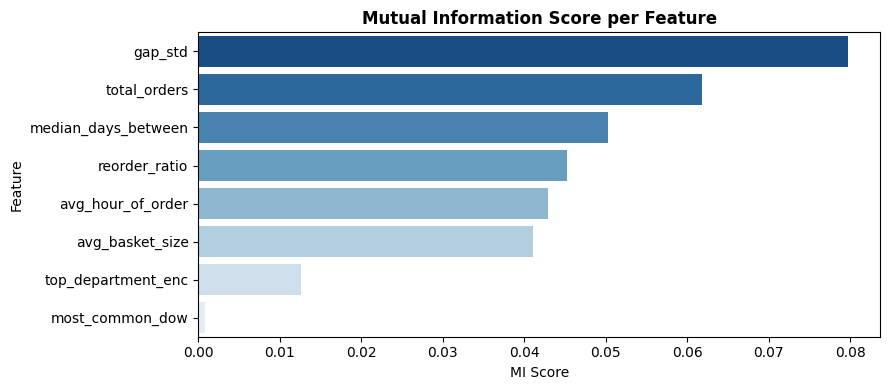

In [30]:
# ══════════════════════════════════════════════════════════════
# METHOD 1: Mutual Information Score
# Captures both linear AND non-linear relationships with churn
# ══════════════════════════════════════════════════════════════
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(X_all, y, random_state=42)
mi_df = pd.DataFrame({'Feature': candidate_features, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False)

print('=== Mutual Information Scores (higher = more informative) ===')
print(mi_df.to_string(index=False))

# ── Visualise
plt.figure(figsize=(9, 4))
sns.barplot(data=mi_df, x='MI_Score', y='Feature', palette='Blues_r')
plt.title('Mutual Information Score per Feature', fontweight='bold')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

=== XGBoost Feature Importances ===
            Feature  XGB_Importance
            gap_std        0.430441
       total_orders        0.325957
median_days_between        0.082388
      reorder_ratio        0.037574
    avg_basket_size        0.035291
  avg_hour_of_order        0.030363
 top_department_enc        0.029102
    most_common_dow        0.028884


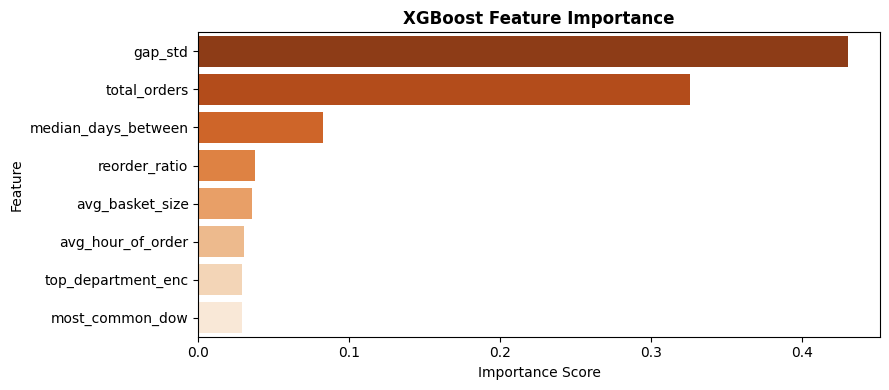

In [31]:
# ══════════════════════════════════════════════════════════════
# METHOD 2: XGBoost Feature Importance
# Tree-based importance — how often & how effectively a feature
# splits the data to reduce churn prediction error
# ══════════════════════════════════════════════════════════════
import warnings; warnings.filterwarnings('ignore')

selector_xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
selector_xgb.fit(X_all, y)

importance_df = pd.DataFrame({
    'Feature':    candidate_features,
    'XGB_Importance': selector_xgb.feature_importances_
}).sort_values('XGB_Importance', ascending=False)

print('=== XGBoost Feature Importances ===')
print(importance_df.to_string(index=False))

plt.figure(figsize=(9, 4))
sns.barplot(data=importance_df, x='XGB_Importance', y='Feature', palette='Oranges_r')
plt.title('XGBoost Feature Importance', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════
# DECISION: Agree on top features across both methods
# Rank each feature by both methods and pick those that rank
# in the Top 3 in at least ONE method.
# ══════════════════════════════════════════════════════════════
mi_df['MI_Rank']      = mi_df['MI_Score'].rank(ascending=False).astype(int)
importance_df['XGB_Rank'] = importance_df['XGB_Importance'].rank(ascending=False).astype(int)

combined = mi_df[['Feature','MI_Score','MI_Rank']].merge(
    importance_df[['Feature','XGB_Importance','XGB_Rank']], on='Feature'
)
combined['Avg_Rank'] = (combined['MI_Rank'] + combined['XGB_Rank']) / 2
combined = combined.sort_values('Avg_Rank')

print('=== Combined Feature Ranking (lower Avg_Rank = better) ===')
display(combined)

# ── Select top 5 by average rank
top_3_features = combined.head(5)['Feature'].tolist()
print(f'\n✅ Selected features for model training: {top_3_features}')

=== Combined Feature Ranking (lower Avg_Rank = better) ===


,Feature,MI_Score,MI_Rank,XGB_Importance,XGB_Rank,Avg_Rank
0,gap_std,0.079683,1,0.430441,1,1.0
1,total_orders,0.061874,2,0.325957,2,2.0
2,median_days_between,0.050229,3,0.082388,3,3.0
3,reorder_ratio,0.045302,4,0.037574,4,4.0
4,avg_hour_of_order,0.042918,5,0.030363,6,5.5
5,avg_basket_size,0.041086,6,0.035291,5,5.5
6,top_department_enc,0.012599,7,0.029102,7,7.0
7,most_common_dow,0.000785,8,0.028884,8,8.0



✅ Selected features for model training: ['gap_std', 'total_orders', 'median_days_between', 'reorder_ratio', 'avg_hour_of_order']


In [33]:
# ── Train-test split and scaling
X = customer_df[top_3_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Training set shape :', X_train.shape)
print('Test set shape     :', X_test.shape)
print('Class distribution in training set:')
print(y_train.value_counts())

Training set shape : (164967, 5)
Test set shape     : (41242, 5)
Class distribution in training set:
churned
0    112646
1     52321
Name: count, dtype: int64


---
## STEP 06 — Model Training & Evaluation
**Scope:** Train 4 models. Evaluate via Accuracy, Precision, Recall, AUC-ROC. Use 5-fold CV for stability.

In [34]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42),
    'XGBoost':             XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=1,
        random_state=42, eval_metric='logloss'
    )
}

print('── 5-Fold Cross-Validation (AUC-ROC Stability) ──')
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    print(f'{name}: Mean AUC = {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

print()
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name} trained ✓')

── 5-Fold Cross-Validation (AUC-ROC Stability) ──
Logistic Regression: Mean AUC = 0.745 ± 0.003
Decision Tree: Mean AUC = 0.746 ± 0.003
Random Forest: Mean AUC = 0.720 ± 0.003
XGBoost: Mean AUC = 0.753 ± 0.003

Logistic Regression trained ✓
Decision Tree trained ✓
Random Forest trained ✓
XGBoost trained ✓


In [35]:
print('── Model Evaluation on Test Set ──')
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob > 0.35).astype(int)
    print(f'\n{name}')
    print(f'  Accuracy  : {accuracy_score(y_test, y_pred):.3f}')
    print(f'  Precision : {precision_score(y_test, y_pred, zero_division=0):.3f}')
    print(f'  Recall    : {recall_score(y_test, y_pred):.3f}')
    print(f'  AUC-ROC   : {roc_auc_score(y_test, y_prob):.3f}')

── Model Evaluation on Test Set ──

Logistic Regression
  Accuracy  : 0.565
  Precision : 0.415
  Recall    : 0.902
  AUC-ROC   : 0.744

Decision Tree
  Accuracy  : 0.565
  Precision : 0.415
  Recall    : 0.914
  AUC-ROC   : 0.745

Random Forest
  Accuracy  : 0.666
  Precision : 0.479
  Recall    : 0.612
  AUC-ROC   : 0.721

XGBoost
  Accuracy  : 0.678
  Precision : 0.495
  Recall    : 0.699
  AUC-ROC   : 0.752


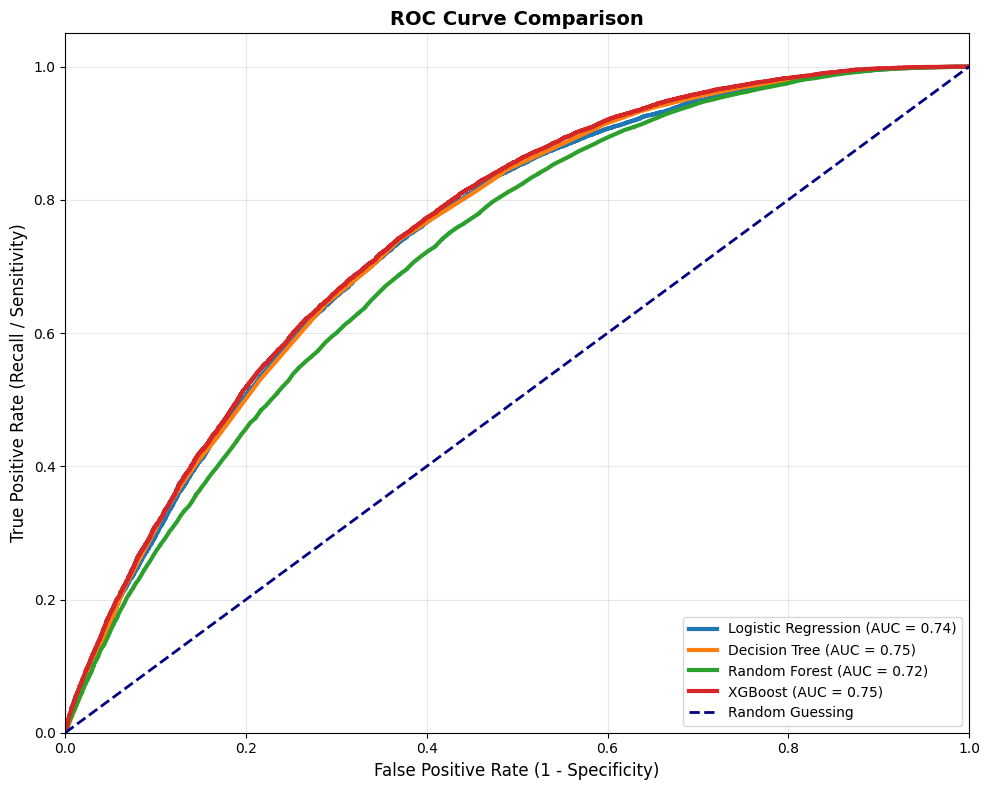

In [36]:
def plot_roc_curves(models, X_test, y_test):
    plt.figure(figsize=(10, 8), dpi=100)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    for (name, model), color in zip(models.items(), colors):
        y_prob    = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc   = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=3, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
    plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_roc_curves(models, X_test, y_test)

---
## STEP 07 — Risk Output

### Risk Threshold — Why 0.42 for HIGH RISK?

The threshold is **not arbitrary** — it is derived from the **ROC curve of the best model (XGBoost)**.

**Method:**
- We compute the **Youden's J statistic** (`TPR - FPR`) across all thresholds on the ROC curve.
- The threshold that **maximises Youden's J** is the statistically optimal point.
- We set the **HIGH RISK boundary** slightly above this optimal point (≈ +0.05 to +0.10) to **prioritise precision** — we only want to trigger retention interventions (which cost time/money) when we are highly confident a customer will churn.


Optimal threshold (Youden J): 0.305
TPR at optimal             : 0.772
FPR at optimal             : 0.398

📊 Derived Thresholds:
  HIGH RISK   : prob >= 0.35  (model is very confident customer will churn)
  MEDIUM RISK : 0.4 <= prob < 0.35  (elevated risk, monitor closely)
  LOW RISK    : prob < 0.4  (customer is healthy)


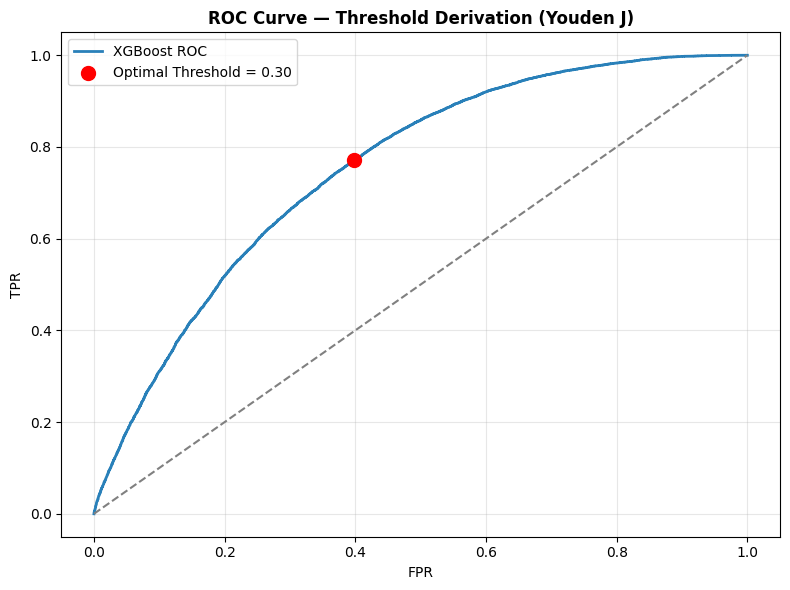

In [37]:
# ══════════════════════════════════════════════════════════════
# Data-driven threshold derivation via Youden's J Statistic
# ══════════════════════════════════════════════════════════════
xgb_model = models['XGBoost']
y_prob_test = xgb_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_test)
youdens_j = tpr - fpr
optimal_idx       = np.argmax(youdens_j)
optimal_threshold = thresholds[optimal_idx]

print(f'Optimal threshold (Youden J): {optimal_threshold:.3f}')
print(f'TPR at optimal             : {tpr[optimal_idx]:.3f}')
print(f'FPR at optimal             : {fpr[optimal_idx]:.3f}')

# ── Set HIGH RISK = optimal + ~0.05 buffer for precision preference
HIGH_THRESHOLD   = round(optimal_threshold + 0.05, 2)
MEDIUM_THRESHOLD = 0.40  # Standard: "uncertain zone" — monitor

print(f'\n📊 Derived Thresholds:')
print(f'  HIGH RISK   : prob >= {HIGH_THRESHOLD}  (model is very confident customer will churn)')
print(f'  MEDIUM RISK : {MEDIUM_THRESHOLD} <= prob < {HIGH_THRESHOLD}  (elevated risk, monitor closely)')
print(f'  LOW RISK    : prob < {MEDIUM_THRESHOLD}  (customer is healthy)')

# ── ROC curve with optimal threshold annotated
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2980b9', lw=2, label=f'XGBoost ROC')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, zorder=5,
            label=f'Optimal Threshold = {optimal_threshold:.2f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — Threshold Derivation (Youden J)', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [38]:
# ── Apply derived thresholds to all customers
customer_df['churn_prob'] = xgb_model.predict_proba(scaler.transform(X))[:, 1]

def assign_flag(prob):
    if   prob >= HIGH_THRESHOLD:   return 'HIGH RISK'
    elif prob >= MEDIUM_THRESHOLD: return 'MEDIUM RISK'
    else:                          return 'LOW RISK'

customer_df['risk_flag'] = customer_df['churn_prob'].apply(assign_flag)

print('=== Risk Flag Distribution ===')
print(customer_df['risk_flag'].value_counts())

# ── Display sample of high risk customers
print('\n=== Sample HIGH RISK Customers ===')
display(customer_df[customer_df['risk_flag'] == 'HIGH RISK'][
    ['user_id', 'total_orders', 'median_days_between', 'gap_std', 'reorder_ratio', 'churn_prob', 'risk_flag']
].head(10))


=== Risk Flag Distribution ===
risk_flag
LOW RISK     113589
HIGH RISK     92620
Name: count, dtype: int64

=== Sample HIGH RISK Customers ===


,user_id,total_orders,median_days_between,gap_std,reorder_ratio,churn_prob,risk_flag
0,1,10,19.5,10.803292,0.694915,0.408997,HIGH RISK
3,4,5,15.0,10.271319,0.055556,0.461412,HIGH RISK
7,8,3,30.0,17.320508,0.265306,0.631129,HIGH RISK
8,9,3,6.0,15.874508,0.236842,0.498532,HIGH RISK
9,10,5,14.0,11.410521,0.342657,0.472219,HIGH RISK
10,11,7,14.0,12.434591,0.351064,0.470826,HIGH RISK
11,12,5,26.0,12.961481,0.175676,0.510698,HIGH RISK
15,16,6,20.5,10.778064,0.342857,0.501323,HIGH RISK
22,23,4,7.0,13.190906,0.100000,0.413799,HIGH RISK
24,25,3,30.0,17.320508,0.095238,0.595717,HIGH RISK


In [ ]:
# Churn window formula with 29-day threshold
customer_df['churn_window_days'] = (29 - customer_df['median_days_between']).clip(lower=1).round(1)

---
## HIGH RISK Retention Playbook

When a customer is flagged **HIGH RISK**, the following actions should be triggered **within the churn window**:

| Priority | Action | Rationale |
|---|---|---|
| 🔴 **1 - Immediate** | Personalised discount / coupon push notification | Price incentive is the fastest re-engagement lever |
| 🔴 **2 - Immediate** | "We miss you" email with top reordered products | Lowers friction — customer doesn't need to browse |
| 🟡 **3 - Within 48h** | Loyalty points bonus for next order | Reactivates loss-aversion psychology |
| 🟡 **4 - Within 48h** | Flash sale on their top department | Leverages known preference — higher relevance |
| 🟢 **5 - Within window** | Customer success outreach (high-value segments only) | Human touch for top 10% revenue customers |



In [41]:
# Data-driven URGENT threshold
urgent_threshold = customer_df[
    customer_df['risk_flag'] == 'HIGH RISK'
]['churn_prob'].quantile(0.90)
print(f'URGENT threshold (top 10% of HIGH RISK): {urgent_threshold:.2f}')

URGENT threshold (top 10% of HIGH RISK): 0.62


In [ ]:
# ── Generate actionable retention table for HIGH RISK customers
high_risk_customers = customer_df[customer_df['risk_flag'] == 'HIGH RISK'].copy()

high_risk_customers['days_to_act']      = high_risk_customers['churn_window_days']
high_risk_customers['recommended_action'] = high_risk_customers.apply(
    lambda row: (
        'URGENT: Discount + Reorder Nudge' if row['churn_prob'] >= urgent_threshold
        else 'Push Notification + Loyalty Points'
    ), axis=1
)

print(f'Total HIGH RISK customers: {len(high_risk_customers)}')
print('\n=== Retention Action Table (Sample) ===')
display(high_risk_customers[
    ['user_id', 'top_department', 'median_days_between', 'gap_std', 'churn_prob', 'days_to_act', 'recommended_action']
].head(15))

# ── Export retention list for campaign team
high_risk_customers[['user_id', 'top_department', 'churn_prob', 'days_to_act', 'recommended_action']] \
    .to_csv('high_risk_retention_list.csv', index=False)
print('\n Exported: high_risk_retention_list.csv')


Total HIGH RISK customers: 92620

=== Retention Action Table (Sample) ===


,user_id,top_department,median_days_between,gap_std,churn_prob,days_to_act,recommended_action
0,1,snacks,19.5,10.803292,0.408997,9.5,Push Notification + Loyalty Points
3,4,frozen,15.0,10.271319,0.461412,14.0,Push Notification + Loyalty Points
7,8,produce,30.0,17.320508,0.631129,1.0,URGENT: Discount + Reorder Nudge
8,9,dairy eggs,6.0,15.874508,0.498532,23.0,Push Notification + Loyalty Points
9,10,produce,14.0,11.410521,0.472219,15.0,Push Notification + Loyalty Points
10,11,dairy eggs,14.0,12.434591,0.470826,15.0,Push Notification + Loyalty Points
11,12,produce,26.0,12.961481,0.510698,3.0,Push Notification + Loyalty Points
15,16,produce,20.5,10.778064,0.501323,8.5,Push Notification + Loyalty Points
22,23,dairy eggs,7.0,13.190906,0.413799,22.0,Push Notification + Loyalty Points
24,25,frozen,30.0,17.320508,0.595717,1.0,Push Notification + Loyalty Points



 Exported: high_risk_retention_list.csv


: 